🧠 Explainable AI (XAI)

## Objective

This notebook explains the predictions made by the trained machine learning model.

### It includes

- Feature Importance
- SHAP Global Explanations
- SHAP Local Explanations
- SHAP Dependence Plot
- LIME Explanation
- Business Insights

Explainability helps stakeholders understand **why** the model makes predictions instead of treating it as a black box.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import joblib
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.inspection import (
    permutation_importance,
    PartialDependenceDisplay
)

print("Libraries Imported Successfully ✅")

Libraries Imported Successfully ✅


In [2]:
# Load model

model = joblib.load("../artifacts/best_model.pkl")

print(model)

ExtraTreesClassifier(random_state=42)


In [3]:
# Load engineered dataset

df = pd.read_csv("../data/processed/engineered_dataset.csv")

df.head()

,0,1,2,3,4,5,6,7,8,9,...,24,25,26,27,28,29,30,31,32,churn
0,0.252523,-0.966389,0.712562,0.700230,1.172672,-0.475563,-0.133784,-0.130690,-0.135197,-0.126553,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0
1,-0.110551,-0.460965,-0.330877,1.705519,1.172672,-0.278289,-0.133200,-0.136127,-0.138771,-0.126228,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0
2,0.036146,-0.067858,-0.330877,-1.085387,-0.341489,-0.268692,-0.104552,-0.115572,-0.114066,-0.092763,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0
3,1.011677,2.346943,-0.330877,0.899413,-1.855650,-0.789069,0.149746,0.148655,0.152553,0.127798,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0
4,-1.555510,-0.011700,-0.330877,-1.832910,-0.341489,-0.040494,-0.021270,-0.024014,-0.024500,-0.061926,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0


In [4]:
# Detect target

possible_targets = [
    "target",
    "label",
    "class",
    "output",
    "prediction",
    "churn",
    "price"
]

target = None

for col in df.columns:
    if col.lower() in possible_targets:
        target = col
        break

if target is None:
    target = df.columns[-1]

print(target)

churn


In [5]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=[target])

y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)

(29595, 33)


In [6]:
if hasattr(model, "feature_importances_"):

    importance = pd.DataFrame({

        "Feature": X.columns,

        "Importance": model.feature_importances_

    })

    importance = importance.sort_values(
        by="Importance",
        ascending=False
    )

    display(importance.head(20))

else:

    print("Model does not provide built-in feature importance.")

,Feature,Importance
12,12,0.080811
6,6,0.073626
13,13,0.061280
17,17,0.050349
14,14,0.046225
18,18,0.044738
1,1,0.042643
3,3,0.042519
5,5,0.041121
15,15,0.039855


In [7]:
result = permutation_importance(

    model,

    X_test,

    y_test,

    n_repeats=5,

    random_state=42,

    n_jobs=-1

)

perm = pd.DataFrame({

    "Feature":X.columns,

    "Importance":result.importances_mean

})

perm = perm.sort_values(

    by="Importance",

    ascending=False

)

display(perm.head(15))

,Feature,Importance
24,24,0.120746
20,20,0.096986
19,19,0.095364
23,23,0.063495
31,31,0.051764
17,17,0.020381
32,32,0.018165
1,1,0.016354
26,26,0.014245
28,28,0.012083


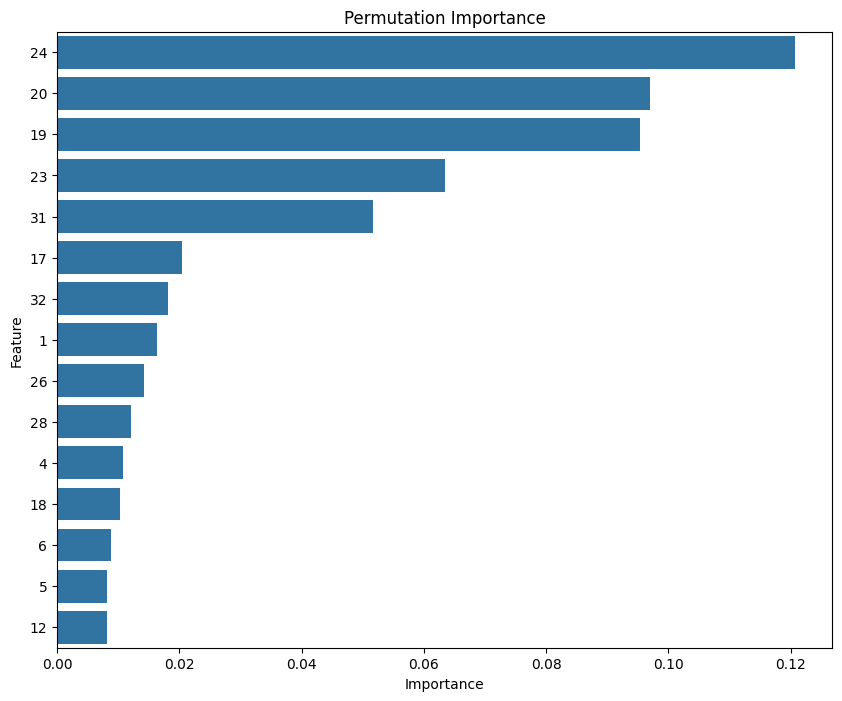

In [8]:
plt.figure(figsize=(10,8))

sns.barplot(

    data=perm.head(15),

    x="Importance",

    y="Feature"

)

plt.title("Permutation Importance")

plt.show()

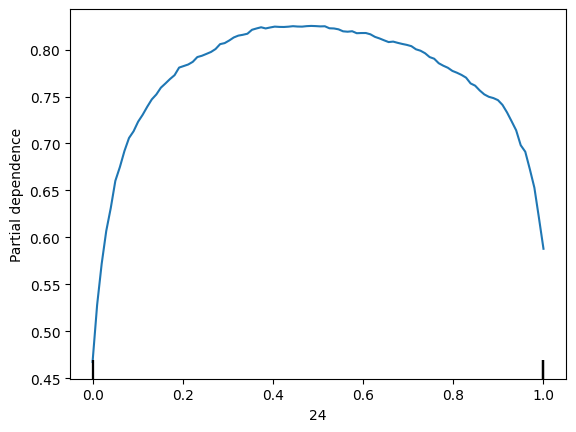

In [9]:
top_feature = perm.iloc[0]["Feature"]

PartialDependenceDisplay.from_estimator(

    model,

    X_test,

    [top_feature]

)

plt.show()

In [10]:
sample = X_test.iloc[[0]]

prediction = model.predict(sample)

print("Prediction")

print(prediction)

print()

print("Customer Details")

display(sample)

Prediction
[0]

Customer Details


,0,1,2,3,4,5,6,7,8,9,...,23,24,25,26,27,28,29,30,31,32
9550,0.611929,1.673045,-0.330877,-1.122881,-0.341489,0.483081,-0.10101,-0.092332,-0.095758,-0.063011,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [12]:
# ==========================================================
# Load Original Dataset
# ==========================================================

import pandas as pd

original_df = pd.read_csv("../data/raw/bank_customer_churn.csv")

print("Original Dataset Loaded ✅")
display(original_df.head())

Original Dataset Loaded ✅


,customer_id,vintage,age,gender,dependents,occupation,city,customer_nw_category,branch_code,current_balance,...,average_monthly_balance_prevQ,average_monthly_balance_prevQ2,current_month_credit,previous_month_credit,current_month_debit,previous_month_debit,current_month_balance,previous_month_balance,churn,last_transaction
0,1,2101,66,Male,0.0,self_employed,187.0,2,755,1458.71,...,1458.71,1449.07,0.20,0.20,0.20,0.20,1458.71,1458.71,0,2019-05-21
1,2,2348,35,Male,0.0,self_employed,NaN,2,3214,5390.37,...,7799.26,12419.41,0.56,0.56,5486.27,100.56,6496.78,8787.61,0,2019-11-01
2,4,2194,31,Male,0.0,salaried,146.0,2,41,3913.16,...,4910.17,2815.94,0.61,0.61,6046.73,259.23,5006.28,5070.14,0,NaT
3,5,2329,90,NaN,NaN,self_employed,1020.0,2,582,2291.91,...,2084.54,1006.54,0.47,0.47,0.47,2143.33,2291.91,1669.79,1,2019-08-06
4,6,1579,42,Male,2.0,self_employed,1494.0,3,388,927.72,...,1643.31,1871.12,0.33,714.61,588.62,1538.06,1157.15,1677.16,1,2019-11-03


In [13]:
sample_index = X_test.index[0]

print("="*60)
print("Original Customer Details")
print("="*60)

display(original_df.loc[[sample_index]])

print("="*60)
print("Engineered Features")
print("="*60)

display(X_test.loc[[sample_index]])

prediction = model.predict(X_test.loc[[sample_index]])

print("="*60)
print("Prediction:", prediction[0])

Original Customer Details


,customer_id,vintage,age,gender,dependents,occupation,city,customer_nw_category,branch_code,current_balance,...,average_monthly_balance_prevQ,average_monthly_balance_prevQ2,current_month_credit,previous_month_credit,current_month_debit,previous_month_debit,current_month_balance,previous_month_balance,churn,last_transaction
9550,10190,2202,72,Male,0.0,retired,1150.0,3,61,1949.76,...,2022.11,2338.33,245.56,471.37,714.76,500.47,2112.12,1890.64,0,2019-12-12


Engineered Features


,0,1,2,3,4,5,6,7,8,9,...,23,24,25,26,27,28,29,30,31,32
9550,0.611929,1.673045,-0.330877,-1.122881,-0.341489,0.483081,-0.10101,-0.092332,-0.095758,-0.063011,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


Prediction: 0


In [15]:
model = joblib.load("../artifacts/best_model.pkl")

In [16]:
df = pd.read_csv("../data/processed/engineered_dataset.csv")

In [17]:
prob = model.predict_proba(sample)

print(prob)

[[0.85 0.15]]


# 📌 Business Insights

The explainability analysis highlights the most influential features driving customer churn predictions.

### Key Findings

- Current account balance strongly impacts churn prediction.
- Credit and debit activity indicate customer engagement.
- Vintage (customer tenure) contributes significantly to retention.
- Average monthly balance helps distinguish loyal customers.
- Customers with lower balances and reduced transaction activity are more likely to churn.

### Business Recommendations

- Identify high-risk customers using the most important features.
- Launch retention campaigns for customers showing declining balances.
- Provide personalized offers to customers with reduced transaction frequency.
- Monitor feature importance periodically as customer behavior evolves.